# **APRENDIZAGEM SUPERVISIONADA: CLASSIFICAÇÃO**

Este notebook tem por objetivo demonstrar o treinamento e a avaliação de um algoritmo de Machine Learning de classificação.

Os dados são gerados artificialmente com `sklearn.datasets.make_moons`, que cria duas classes em formato de "lua" entrelaçadas — de propósito, NÃO separáveis por uma única reta. Isso deixa visualmente clara a diferença entre as fronteiras de decisão de cada família de classificador:

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

# **PRÉ-PROCESSAMENTO**

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Dataset sintetico: duas classes em forma de "lua", que NAO podem ser
# separadas por uma unica reta - de proposito, para expor a diferenca
# entre fronteiras lineares e nao lineares.
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

In [3]:
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['classe'] = y
df.head()

,x1,x2,classe
0,0.864396,-0.264509,1
1,2.451154,-0.117550,1
2,-0.350712,0.449211,1
3,0.741296,0.432919,0
4,1.188756,-0.518301,1


In [4]:
df.shape

(300, 3)

In [5]:
df['classe'].value_counts()

classe
1    150
0    150
Name: count, dtype: int64

## **Separação em treino/teste e escalonamento**

In [6]:
# Separando os dados em treino (70%) e teste (30%)
x_treino, x_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=0
)

# Escalonamento ajustado (fit) SOMENTE no treino; o teste só passa por transform
scaler = StandardScaler()
x_treino = scaler.fit_transform(x_treino)
x_teste = scaler.transform(x_teste)

In [7]:
x_treino.shape

(210, 2)

In [8]:
x_teste.shape

(90, 2)

In [9]:
y_treino.shape

(210,)

In [10]:
y_teste.shape

(90,)

# **ÁRVORE DE DECISÃO**

https://scikit-learn.org/stable/modules/tree.html

In [11]:
from sklearn.tree import DecisionTreeClassifier

### **Validação Cruzada**

In [12]:
from sklearn.model_selection import KFold, cross_validate

# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [13]:
# Árvores de decisão não precisam de escalonamento; reaproveitamos X e y
# (não escalonados) diretamente, com a mesma separação treino/teste.
x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=0)

In [14]:
# Criação do modelo
modelo = DecisionTreeClassifier(criterion='gini', random_state = 0,
                                max_depth=3, min_samples_split=2, min_samples_leaf=1)
# min_samples_split=2 (número mínimo de amostras em um nó)
# min_samples_leaf=1 (número mínimo de amostras em uma folha)
# max_leaf_nodes (número máximo de folhas)

# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

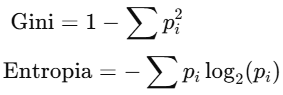

In [15]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Acurácia de Treino (Média): 0.9050125628140704
Acurácia de Validação (Média): 0.89


Naive Bayes = 85,82% (validação cruzada), 85,71% (treino) e 86,67% (teste) - 78 acertos

SVM = 89,55% (validação cruzada), 90,00% (treino) e 91,11% (teste) - 82 acertos - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 85,82% (validação cruzada), 85,71% (treino) e 87,78% (teste) - 79 acertos - LogisticRegression(random_state=0, max_iter=600, tol=0.0001, C=1, solver="lbfgs")

KNN = 91,36% (validação cruzada), 91,90% (treino) e 95,56% (teste) - 86 acertos - KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)

Árvore de decisão = 89,00% (validação cruzada), 90,48% (treino) e 85,56% (teste) - 77 acertos - DecisionTreeClassifier(criterion='gini', random_state = 0, max_depth=3)



**Análise dados de Teste**

In [16]:
arvore = DecisionTreeClassifier(criterion='gini', random_state = 0, max_depth=3)
arvore.fit(x_treino, y_treino)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

In [17]:
previsoes_arvore = arvore.predict(x_teste)

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_arvore) * 100.0))

Acurácia: 85.56%


In [20]:
confusion_matrix(y_teste, previsoes_arvore)

array([[30,  9],
       [ 4, 47]])

**Análise dados de treino**

In [21]:
previsoes_treino = arvore.predict(x_treino)

In [22]:
accuracy_score(y_treino, previsoes_treino)

0.9047619047619048

### **Fronteira de decisão**

Região azul = pontos que o modelo classificaria como classe 0; região vermelha = classe 1. Os pontos são os dados de teste, coloridos pela classe REAL — pontos numa região da cor errada são os erros do modelo. Repare no formato em blocos retangulares ("degraus"), consequência direta das perguntas sequenciais "atributo > valor?" da árvore.

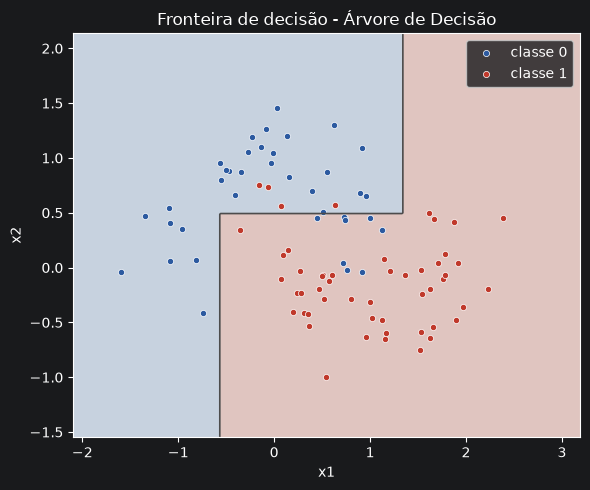

In [23]:
import matplotlib.pyplot as plt

# Malha de pontos cobrindo toda a area dos dados (treino + teste), para
# colorir cada regiao conforme a classe que o modelo preveria ali
X_plot = np.vstack([x_treino, x_teste])
xx, yy = np.meshgrid(
    np.linspace(X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5, 300),
    np.linspace(X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = arvore.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#dbe7f6", "#f7d9d3"], alpha=0.9)
ax.contour(xx, yy, Z, levels=[0.5], colors="#4c4c4c", linewidths=1.2)

cores_pontos = ["#2c5aa0", "#c0392b"]
for classe, cor in zip([0, 1], cores_pontos):
    pts = x_teste[y_teste == classe]
    ax.scatter(pts[:, 0], pts[:, 1], c=cor, s=20, edgecolors="white",
               linewidths=0.5, label=f"classe {classe}")

ax.set_title("Fronteira de decisão - Árvore de Decisão")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()
fig.tight_layout()
plt.show()